# **XGBoost**

D8 solutions

As a baseline, the current collision-parts forecast (using the generic model) has a WMAPE of around 70% using a 2-month lag and a 3-month rolling average.

Forecast requirements:
- **Granularity:** Provide monthly forecasts at the SKU level, for the defined collision parts scope.
- **Horizon**: Forecast 18 months ahead, updated monthly.
- **Accuracy metric:** Use WMAPE, assessed with:
    - 3-month forecast lag (forecasts are judged against actuals two months later)
    - 3-month rolling average of WMAPE (to smooth month-to-month noise)
- **Benchmarking:** Compare results against the current baseline model, with improvement reported in WMAPE points and %.
- **Backtesting:** Use a rolling-origin backtest that matches the real operating cadence (train on history, predict forward with the 3-month lag).
- **Edge cases:** Be explicit about how you handle:
    - Zero-demand months (common in collision parts)
    - New / discontinued / superseded SKUs
- **Outputs:** Provide forecasts plus a short explanation of what drives performance (where it works well, where it struggles, and why) and provide the meaning of the features used.

**Load libraries**

In [2]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gdown
import os
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')


**Load data**

In [3]:
# define where to write data
output_dir = r'C:\Users\jsurya\OneDrive\Documents\Cambridge course\Employer project'

# retrieve data
gdown.download_folder(
    'https://drive.google.com/drive/folders/1mbF_-DhueN4I6plKmP3YI6AnKKa0LNNC',
    output=output_dir,
    quiet=False
)

# sales_collision
sales_collision = pd.read_csv(os.path.join(output_dir, 'sales_collision.csv'))

Retrieving folder contents


Retrieving folder 1Me6bDJHpqrT-C0k-dscXan8LByCESPkH Croston (SBA) (David)
Processing file 1O3QNR8W7x0daTJby5HbeJl39fcE5Grtm alpha_sensitivity.png
Processing file 1InLYcTr9WBeSVEQlW0a1_nByUXCYk6em Croston SBA Results Interpretation.docx
Processing file 1sGj3oE9Cbr4egxFpZN30e_5c8N40f7yU Croston.ipynb
Processing file 1rvZWLmK8lgoQoeMaohfbwCAX8PI8wYh3 sba_forecast_sample.png
Processing file 1mN6lTalylPEFznHAhhCt_KEhtUGOccOv sba_forecasts_18m.csv
Processing file 10hrZRYvF1WWv1f82EhV3p9nI9SDMH0ej sba_wmape_distribution.png
Retrieving folder 1_jKWbc-P8PLg-esSdzQ-jX8yCyn4kRbA LSTM (Carlota)
Retrieving folder 1mSd_LPM4vEOo40r71h2ADC-zOjww-vUP LSTM Results
Processing file 1vKpIIqQzbIDOOOR1BxtqRy4pYc9DUY2Z lstm_backtest_metrics.csv
Processing file 1YWBO26upcXfmG0J-qKl1JU31_jH4IrsM lstm_backtest_predictions.csv
Processing file 1RrUDJjq1mBN9iHh8B2lFsTFowswd7s3o lstm_forecast_sample.png
Processing file 1d7QJNro3PvRdLIMUG7kmlBveMlbTUvAz lstm_forecasts_18m.csv
Processing file 1mv27aitjMLMmVlTdSDbqFnae

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1O3QNR8W7x0daTJby5HbeJl39fcE5Grtm
To: /content/C:\Users\jsurya\OneDrive\Documents\Cambridge course\Employer project/Croston (SBA) (David)/alpha_sensitivity.png
100%|██████████| 283k/283k [00:00<00:00, 5.24MB/s]
Downloading...
From: https://drive.google.com/uc?id=1InLYcTr9WBeSVEQlW0a1_nByUXCYk6em
To: /content/C:\Users\jsurya\OneDrive\Documents\Cambridge course\Employer project/Croston (SBA) (David)/Croston SBA Results Interpretation.docx
100%|██████████| 15.7k/15.7k [00:00<00:00, 22.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1sGj3oE9Cbr4egxFpZN30e_5c8N40f7yU
To: /content/C:\Users\jsurya\OneDrive\Documents\Cambridge course\Employer project/Croston (SBA) (David)/Croston.ipynb
100%|██████████| 749k/749k [00:00<00:00, 7.65MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rvZWLmK8lgoQoeMaohfbwCAX8PI8wYh3
To: /con

**Basic checks to assess if data is correctly loaded**

There should be the following number of rows: 180422

Unique SKUs: 8097

Number by demand_type (Total demand)

- Smooth ... 972 (156317)
- Intermittent ... 6593 (52809)
- Lumpy ... 381 (12349)
- Erratic ... 124 (16049)

In [ ]:
# check shape
print(f"There are {sales_collision.shape[0]} rows and {sales_collision.shape[1]} features")

There are 180422 rows and 48 features


In [ ]:
# unique SKUs
print(sales_collision['sku_id'].nunique())

8097


In [ ]:
# print demand types
print(sales_collision['demand_type'].unique())

['Intermittent' 'Lumpy' 'Smooth' 'Erratic' 'No demand observed']


In [ ]:
# get table of demand_type
print(sales_collision.groupby('sku_id')['demand_type'].first().value_counts())

demand_type
Intermittent          6593
Smooth                 972
Lumpy                  381
Erratic                124
No demand observed      27
Name: count, dtype: int64


In [ ]:
print(sales_collision.groupby('demand_type')['demand'].sum())

demand_type
Erratic                16049.0
Intermittent           52809.0
Lumpy                  12349.0
No demand observed         0.0
Smooth                156317.0
Name: demand, dtype: float64


In [ ]:
# add total demand by sku_id as additional column
total_demand_by_sku = sales_collision.groupby('sku_id')['demand'].sum().rename('total_demand_sku')
sales_collision = sales_collision.merge(total_demand_by_sku, on='sku_id', how='left')

# mark top 20% SKUs by total demand
threshold = sales_collision['total_demand_sku'].quantile(0.80)
sales_collision['is_top20pct'] = (sales_collision['total_demand_sku'] >= threshold).astype(int)

# mark top 5% SKUs by total demand
threshold = sales_collision['total_demand_sku'].quantile(0.95)
sales_collision['is_top5pct'] = (sales_collision['total_demand_sku'] >= threshold).astype(int)

**XGBoost**

In [ ]:
# Set up and feature engineering

FORECAST_LAG = 3    # months between forecast origin and target
N_FORECAST   = 18   # months ahead to forecast
MIN_TRAIN    = 100  # minimum training rows per backtest fold

# ── Base dataframe ─────────────────────────────────────────────────────────────
df = sales_collision[['sku_id', 'month', 'demand', 'demand_type']].copy()
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['sku_id', 'month']).reset_index(drop=True)

# ── Feature engineering ────────────────────────────────────────────────────────
def engineer_features(data):
    data = data.sort_values(['sku_id', 'month']).copy()
    g = data.groupby('sku_id')['demand']

    for l in [3, 4, 5, 6, 9, 12, 15]:
        data[f'lag_{l}m'] = g.shift(l)

    for w in [3, 6, 12]:
        data[f'roll_mean_{w}m'] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).mean())
        data[f'roll_std_{w}m']  = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).std().fillna(0))
        data[f'roll_max_{w}m']  = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).max())

    data['_iz'] = (data['demand'] == 0).astype(float)
    gz = data.groupby('sku_id')['_iz']
    data['zero_share_6m']  = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(6,  min_periods=1).mean())
    data['zero_share_12m'] = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(12, min_periods=1).mean())
    data.drop(columns=['_iz'], inplace=True)

    data['month_of_year'] = data['month'].dt.month
    data['quarter']       = data['month'].dt.quarter
    data['year']          = data['month'].dt.year

    first_sale = (
        data[data['demand'] > 0].groupby('sku_id')['month'].min().rename('_first_sale')
    )
    data = data.merge(first_sale, on='sku_id', how='left')
    data['sku_age_months'] = (
        (data['month'].dt.year  - data['_first_sale'].dt.year)  * 12
        + (data['month'].dt.month - data['_first_sale'].dt.month)
    ).clip(lower=0).fillna(0)
    data['is_new_sku']     = (data['sku_age_months'] < 6).astype(int)
    data.drop(columns=['_first_sale'], inplace=True)

    return data

FEATURE_COLS = (
    [f'lag_{l}m'         for l in [3, 4, 5, 6, 9, 12, 15]]
    + [f'roll_mean_{w}m' for w in [3, 6, 12]]
    + [f'roll_std_{w}m'  for w in [3, 6, 12]]
    + [f'roll_max_{w}m'  for w in [3, 6, 12]]
    + ['zero_share_6m', 'zero_share_12m',
       'month_of_year', 'quarter', 'year', 'sku_age_months', 'is_new_sku']
)

df = engineer_features(df)
print(f"Dataset: {df.shape[0]:,} rows | {len(FEATURE_COLS)} features")
print("NaN share (top 5):")
print(df[FEATURE_COLS].isnull().mean().sort_values(ascending=False).head())


Dataset: 180,422 rows | 23 features
NaN share (top 5):
lag_15m    0.630422
lag_12m    0.514699
lag_9m     0.392801
lag_6m     0.265372
lag_5m     0.221813
dtype: float64


<u>Interpretation</u>

*23 features* — the engineered feature columns defined in FEATURE_COLS (lags, rolling stats, zero share, calendar, SKU age).

*NaN share* — the fraction of rows where that feature is missing:
- lag_15m = 0.63 → 63% of rows have no value for demand 15 months ago
- lag_12m = 0.51 → 51% missing for 12 months ago
- etc.

*Why so many NaNs?* Two reasons:
1. Short history: if a SKU only entered the data 6 months ago, it has no demand value from 12 or 15 months ago — those lags simply don't exist yet.
2. Lag anchoring: lags start at lag_3m (not lag_1m), so even SKUs with a full history lose the first 3 rows.

*Is this a problem?* No — XGBoost handles NaNs natively by learning which branch direction is best for missing values. The dropna(subset=feature_cols) in the backtest only drops rows where all features are missing, which would be SKUs with fewer than 3 months of history (essentially brand new SKUs with no usable signal at all).


In [ ]:
# WMAPE + Baseline
# ── WMAPE ──────────────────────────────────────────────────────────────────────
# Weighted by actual demand so large-volume SKUs count more.
def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = y_true.sum()
    return np.nan if denom == 0 else np.abs(y_true - y_pred).sum() / denom

# ── Baseline: 3-month rolling average of lag-3 demand ─────────────────────────
# Mirrors the real operating cadence: at forecast origin T, use the average of
# the three most recent known months (T, T-1, T-2) to predict T+3.
def baseline_wmape(data):
    d = data.sort_values(['sku_id', 'month']).copy()
    d['_bl'] = d.groupby('sku_id')['demand'].transform(
        lambda x: x.shift(FORECAST_LAG).rolling(3, min_periods=1).mean()
    )
    valid = d.dropna(subset=['_bl'])
    return wmape(valid['demand'].values, valid['_bl'].values)


In [ ]:
# Rolling-origin Backtest + Training

# ── Rolling-origin backtest ────────────────────────────────────────────────────
# At each cutoff month: train on all data up to cutoff, predict cutoff + FORECAST_LAG.
# Mirrors real cadence: forecast is made 3 months before the target period.
def rolling_backtest(data, feature_cols, min_train=MIN_TRAIN):
    data      = data.sort_values('month')
    months    = sorted(data['month'].unique())
    month_set = set(months)
    results   = []

    for cutoff in months:
        pred_month = cutoff + pd.DateOffset(months=FORECAST_LAG)
        if pred_month not in month_set:
            continue

        train = data[data['month'] <= cutoff].dropna(subset=feature_cols)
        test  = data[data['month'] == pred_month].dropna(subset=feature_cols)

        if len(train) < min_train or len(test) == 0:
            continue

        model = XGBRegressor(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
            objective='reg:squarederror', random_state=42, n_jobs=-1
        )
        model.fit(train[feature_cols], train['demand'], verbose=False)
        preds = model.predict(test[feature_cols]).clip(min=0)

        results.append({
            'cutoff':     cutoff,
            'pred_month': pred_month,
            'wmape':      wmape(test['demand'].values, preds),
            'model':      model
        })

    return results

# ── Train per demand_type ──────────────────────────────────────────────────────
# 'No demand observed' SKUs are excluded: no history to train on, forecast = 0.
DEMAND_TYPES = [dt for dt in df['demand_type'].dropna().unique()
                if dt != 'No demand observed']

models       = {}   # best (most recent) model per demand_type
summary_rows = []

for dt in DEMAND_TYPES:
    subset = df[df['demand_type'] == dt].copy()
    n_skus = subset['sku_id'].nunique()
    print(f"\n{'─'*58}\n  {dt}  |  {n_skus:,} SKUs")

    bl = baseline_wmape(subset)
    bt = rolling_backtest(subset, FEATURE_COLS)

    if not bt:
        print("  Not enough data for backtest.")
        continue

    wmapes = pd.Series([r['wmape'] for r in bt if not np.isnan(r['wmape'])])
    xgb_w  = wmapes.rolling(3, min_periods=1).mean().mean()   # 3-month rolling avg WMAPE
    imp    = bl - xgb_w

    print(f"  Baseline WMAPE (3m rolling avg) : {bl:.4f}")
    print(f"  XGBoost WMAPE  (3m rolling avg) : {xgb_w:.4f}")
    print(f"  Improvement                     : {imp:+.4f}  ({imp/bl*100:+.1f}%)")

    models[dt] = bt[-1]['model']   # trained on the most data

    summary_rows.append({
        'demand_type':     dt,
        'n_skus':          n_skus,
        'baseline_wmape':  round(bl,          4),
        'xgb_wmape':       round(xgb_w,       4),
        'improvement_pts': round(imp,          4),
        'improvement_pct': round(imp/bl*100,   2)
    })

summary_df = pd.DataFrame(summary_rows)
print(f"\n{'═'*58}\nSUMMARY")
display(summary_df)



──────────────────────────────────────────────────────────
  Lumpy  |  381 SKUs
  Baseline WMAPE (3m rolling avg) : 1.3597
  XGBoost WMAPE  (3m rolling avg) : 1.3508
  Improvement                     : +0.0089  (+0.7%)

──────────────────────────────────────────────────────────
  Intermittent  |  6,593 SKUs
  Baseline WMAPE (3m rolling avg) : 1.4436
  XGBoost WMAPE  (3m rolling avg) : 1.2773
  Improvement                     : +0.1663  (+11.5%)

──────────────────────────────────────────────────────────
  Smooth  |  972 SKUs
  Baseline WMAPE (3m rolling avg) : 0.4663
  XGBoost WMAPE  (3m rolling avg) : 0.4734
  Improvement                     : -0.0071  (-1.5%)

──────────────────────────────────────────────────────────
  Erratic  |  124 SKUs
  Baseline WMAPE (3m rolling avg) : 0.7635
  XGBoost WMAPE  (3m rolling avg) : 0.8245
  Improvement                     : -0.0609  (-8.0%)

══════════════════════════════════════════════════════════
SUMMARY


,demand_type,n_skus,baseline_wmape,xgb_wmape,improvement_pts,improvement_pct
0,Lumpy,381,1.3597,1.3508,0.0089,0.65
1,Intermittent,6593,1.4436,1.2773,0.1663,11.52
2,Smooth,972,0.4663,0.4734,-0.0071,-1.53
3,Erratic,124,0.7635,0.8245,-0.0609,-7.98


Overall WMAPE levels are high (>1.0 for Lumpy and Intermittent), which is normal for collision parts — these SKUs have very sporadic demand with many zero months, making any forecast inherently difficult.

---

Intermittent (6,593 SKUs) — XGBoost wins clearly
- WMAPE drops from 1.44 to 1.28 — an 11.5% improvement
- This is the most important result because Intermittent is by far the largest group (81% of all SKUs)
- XGBoost successfully learns patterns in the sparse demand signal that the simple rolling average misses

Lumpy (381 SKUs) — marginal improvement
- WMAPE drops from 1.36 to 1.35 — only +0.7%
- Essentially a tie. Lumpy demand is irregular in both timing and size, making it hard for any model to improve over a simple average
- Both models perform similarly poorly, suggesting the demand is close to unpredictable at this granularity

Smooth (972 SKUs) — XGBoost slightly worse (-1.5%)
- WMAPE increases from 0.47 to 0.47 — a negligible difference
- Smooth SKUs are the most predictable (lowest WMAPE of all groups at ~0.47)
- The baseline rolling average already captures the pattern well; XGBoost adds no value and slightly overfits

Erratic (124 SKUs) — XGBoost worse (-8.0%)
- WMAPE increases from 0.76 to 0.82
- Erratic demand has high volume but unpredictable timing — XGBoost likely overfits to historical spikes that do not repeat
- Only 124 SKUs, so limited training data makes the model less reliable

---

Key takeaways:
1. Use XGBoost for Intermittent SKUs — clear win
2. For Smooth and Erratic, the baseline rolling average is equally good or better — consider keeping it for those groups
3. All WMAPE values above 1.0 indicate the forecast error exceeds total demand, which is expected for very sporadic collision parts and is an industry-known challenge


In [ ]:
# Generate in-sample XGBoost predictions on historical data
insample_parts = []
for dt, model in models.items():
    subset = df[df['demand_type'] == dt].copy()
    valid  = subset.dropna(subset=FEATURE_COLS)
    preds  = model.predict(valid[FEATURE_COLS]).clip(min=0)
    valid  = valid.copy()
    valid['xgb_insample'] = preds
    insample_parts.append(valid[['sku_id', 'month', 'xgb_insample']])

insample_df = pd.concat(insample_parts, ignore_index=True)
print(f"insample_df: {insample_df.shape[0]:,} rows")


insample_df: 66,580 rows


In [ ]:
# Merge actual demand with in-sample XGBoost predictions
sku_eval = df[['sku_id', 'month', 'demand', 'demand_type']].merge(
    insample_df, on=['sku_id', 'month'], how='inner'
)

# Compute baseline prediction per row (3m rolling avg with forecast lag)
sku_eval = sku_eval.sort_values(['sku_id', 'month'])
sku_eval['baseline'] = sku_eval.groupby('sku_id')['demand'].transform(
    lambda x: x.shift(FORECAST_LAG).rolling(3, min_periods=1).mean()
)
sku_eval = sku_eval.dropna(subset=['baseline', 'xgb_insample'])

# Compute WMAPE per SKU
sku_wmape = (
    sku_eval.groupby(['sku_id', 'demand_type'])
    .apply(lambda g: pd.Series({
        'baseline_wmape':  wmape(g['demand'].values, g['baseline'].values),
        'xgb_wmape':       wmape(g['demand'].values, g['xgb_insample'].values),
        'total_demand':    g['demand'].sum()
    }))
    .reset_index()
)

sku_wmape['improvement_pct'] = (
    (sku_wmape['baseline_wmape'] - sku_wmape['xgb_wmape']) / sku_wmape['baseline_wmape'] * 100
)

# Add total_demand_sku, is_top20pct, is_top5pct from sales_collision
sku_meta = sales_collision[['sku_id', 'total_demand_sku', 'is_top20pct', 'is_top5pct']].drop_duplicates()
sku_wmape = sku_wmape.merge(sku_meta, on='sku_id', how='left')

improved = (
    sku_wmape[sku_wmape['improvement_pct'] > 10]
    .sort_values('total_demand', ascending=False)
    .reset_index(drop=True)
)

print(f"{len(improved)} SKUs improved by >10%")
total_skus = improved['sku_id'].nunique()

for col, label in [('is_top20pct', 'top 20%'), ('is_top5pct', 'top 5%')]:
    # Of improved SKUs: how many are in top tier
    counts = improved[col].value_counts()
    pct_of_improved = (counts / total_skus * 100).round(1)

    # Of all SKUs in top tier: how many are improved
    total_in_tier    = sku_meta[sku_meta[col] == 1]['sku_id'].nunique()
    improved_in_tier = improved[improved[col] == 1]['sku_id'].nunique()
    pct_of_tier      = round(improved_in_tier / total_in_tier * 100, 1)

    print(f"\nImproved SKUs in {label} vs not:")
    print(pd.DataFrame({'count': counts, 'pct_of_improved': pct_of_improved}))
    print(f"  → {improved_in_tier} of {total_in_tier} {label} SKUs are improved ({pct_of_tier}% of all {label} SKUs)")

display(improved[['sku_id', 'demand_type', 'total_demand', 'total_demand_sku', 'is_top20pct', 'is_top5pct', 'baseline_wmape', 'xgb_wmape', 'improvement_pct']])


1896 SKUs improved by >10%

Improved SKUs in top 20% vs not:
             count  pct_of_improved
is_top20pct                        
0             1182             62.3
1              714             37.7
  → 714 of 1325 top 20% SKUs are improved (53.9% of all top 20% SKUs)

Improved SKUs in top 5% vs not:
            count  pct_of_improved
is_top5pct                        
0            1699             89.6
1             197             10.4
  → 197 of 325 top 5% SKUs are improved (60.6% of all top 5% SKUs)


,sku_id,demand_type,total_demand,total_demand_sku,is_top20pct,is_top5pct,baseline_wmape,xgb_wmape,improvement_pct
0,09409M07L01000,Smooth,3897.0,12745.0,1,1,0.466727,0.298806,35.978344
1,09409M07346000,Smooth,2809.0,10211.0,1,1,0.475199,0.338565,28.753049
2,09409M08006000,Erratic,1390.0,3193.0,1,1,0.886451,0.350303,60.482576
3,09409M07355000,Erratic,608.0,1052.0,1,1,0.841831,0.443676,47.296303
4,0911912012000,Smooth,415.0,1105.0,1,1,0.449799,0.192250,57.258787
...,...,...,...,...,...,...,...,...,...
1891,6934052S00000,Intermittent,1.0,7.0,0,0,2.500000,1.793863,28.245500
1892,84851M74L006GS,Intermittent,1.0,5.0,0,0,4.166667,1.740839,58.219854
1893,7211060R00BVW,Intermittent,1.0,4.0,0,0,2.666667,1.534569,42.453680
1894,7211257M10000,Intermittent,1.0,9.0,0,0,3.166667,2.814429,11.123304


In [ ]:
# 18 month recursive forecast

_first_sale = (
    df[df['demand'] > 0]
    .groupby('sku_id')['month'].min()
    .rename('_first_sale')
)

pool = (
    df[df['demand_type'].isin(models)]
    [['sku_id', 'month', 'demand', 'demand_type']]
    .sort_values(['sku_id', 'month'])
    .groupby('sku_id').tail(16)
    .reset_index(drop=True)
    .merge(_first_sale, on='sku_id', how='left')
)

last_month    = df['month'].max()
all_forecasts = []

for h in range(1, N_FORECAST + 1):
    target_month = last_month + pd.DateOffset(months=h)

    skus_meta   = pool[['sku_id', 'demand_type', '_first_sale']].drop_duplicates()
    future_rows = skus_meta.assign(month=target_month, demand=np.nan)

    extended = pd.concat([pool, future_rows], ignore_index=True)
    extended = extended.sort_values(['sku_id', 'month']).copy()

    g = extended.groupby('sku_id')['demand']
    for l in [3, 4, 5, 6, 9, 12, 15]:
        extended[f'lag_{l}m'] = g.shift(l)
    for w in [3, 6, 12]:
        extended[f'roll_mean_{w}m'] = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).mean())
        extended[f'roll_std_{w}m']  = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).std().fillna(0))
        extended[f'roll_max_{w}m']  = g.transform(lambda x: x.shift(FORECAST_LAG).rolling(w, min_periods=1).max())

    extended['_iz'] = (extended['demand'].fillna(0) == 0).astype(float)
    gz = extended.groupby('sku_id')['_iz']
    extended['zero_share_6m']  = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(6,  min_periods=1).mean())
    extended['zero_share_12m'] = gz.transform(lambda x: x.shift(FORECAST_LAG).rolling(12, min_periods=1).mean())

    extended['month_of_year'] = extended['month'].dt.month
    extended['quarter']       = extended['month'].dt.quarter
    extended['year']          = extended['month'].dt.year

    extended['sku_age_months'] = (
        (extended['month'].dt.year  - extended['_first_sale'].dt.year)  * 12
        + (extended['month'].dt.month - extended['_first_sale'].dt.month)
    ).clip(lower=0).fillna(0)
    extended['is_new_sku'] = (extended['sku_age_months'] < 6).astype(int)
    extended.drop(columns=['_iz'], inplace=True)

    target_rows = extended[extended['month'] == target_month].copy()

    fc_parts = []
    for dt, model in models.items():
        rows_dt = target_rows[target_rows['demand_type'] == dt]
        avail   = [c for c in FEATURE_COLS if c in rows_dt.columns]
        valid   = rows_dt.dropna(subset=avail)
        if valid.empty:
            continue
        preds             = model.predict(valid[avail].fillna(0)).clip(min=0)
        valid             = valid.copy()
        valid['forecast'] = preds
        valid['demand']   = preds
        fc_parts.append(valid[['sku_id', 'month', 'demand', 'demand_type', '_first_sale', 'forecast']])

    if not fc_parts:
        continue

    fc_month = pd.concat(fc_parts, ignore_index=True)
    all_forecasts.append(fc_month[['sku_id', 'month', 'forecast', 'demand_type']])

    pool = pd.concat(
        [pool, fc_month[['sku_id', 'month', 'demand', 'demand_type', '_first_sale']]],
        ignore_index=True
    )

    print(f"  h={h:2d}  {target_month.strftime('%Y-%m')}  →  {len(fc_month):,} SKUs")

forecasts_18m = pd.concat(all_forecasts, ignore_index=True)
forecasts_18m['horizon'] = forecasts_18m.groupby('sku_id').cumcount() + 1

print(f"\nForecast complete: {forecasts_18m['sku_id'].nunique():,} SKUs × {N_FORECAST} months")
display(forecasts_18m.head(30))




  h= 1  2026-05  →  6,787 SKUs
  h= 2  2026-06  →  6,787 SKUs
  h= 3  2026-07  →  6,787 SKUs
  h= 4  2026-08  →  6,787 SKUs
  h= 5  2026-09  →  6,787 SKUs
  h= 6  2026-10  →  6,787 SKUs
  h= 7  2026-11  →  6,787 SKUs
  h= 8  2026-12  →  6,787 SKUs
  h= 9  2027-01  →  6,787 SKUs
  h=10  2027-02  →  6,787 SKUs
  h=11  2027-03  →  6,787 SKUs
  h=12  2027-04  →  6,787 SKUs
  h=13  2027-05  →  6,787 SKUs
  h=14  2027-06  →  6,787 SKUs
  h=15  2027-07  →  6,787 SKUs
  h=16  2027-08  →  6,787 SKUs
  h=17  2027-09  →  6,787 SKUs
  h=18  2027-10  →  6,787 SKUs

Forecast complete: 6,787 SKUs × 18 months


,sku_id,month,forecast,demand_type,horizon
0,015500612A000,2026-05-01,0.242232,Lumpy,1
1,02142M0508A000,2026-05-01,0.328053,Lumpy,1
2,083313124A000,2026-05-01,0.261851,Lumpy,1
3,0910010275000,2026-05-01,0.347672,Lumpy,1
4,0911610173000,2026-05-01,0.300715,Lumpy,1
5,0911912007000,2026-05-01,4.500898,Lumpy,1
6,09136M05078000,2026-05-01,0.434671,Lumpy,1
7,0915912051000,2026-05-01,0.328053,Lumpy,1
8,0915912057000,2026-05-01,0.000000,Lumpy,1
9,0915912L02000,2026-05-01,0.261851,Lumpy,1


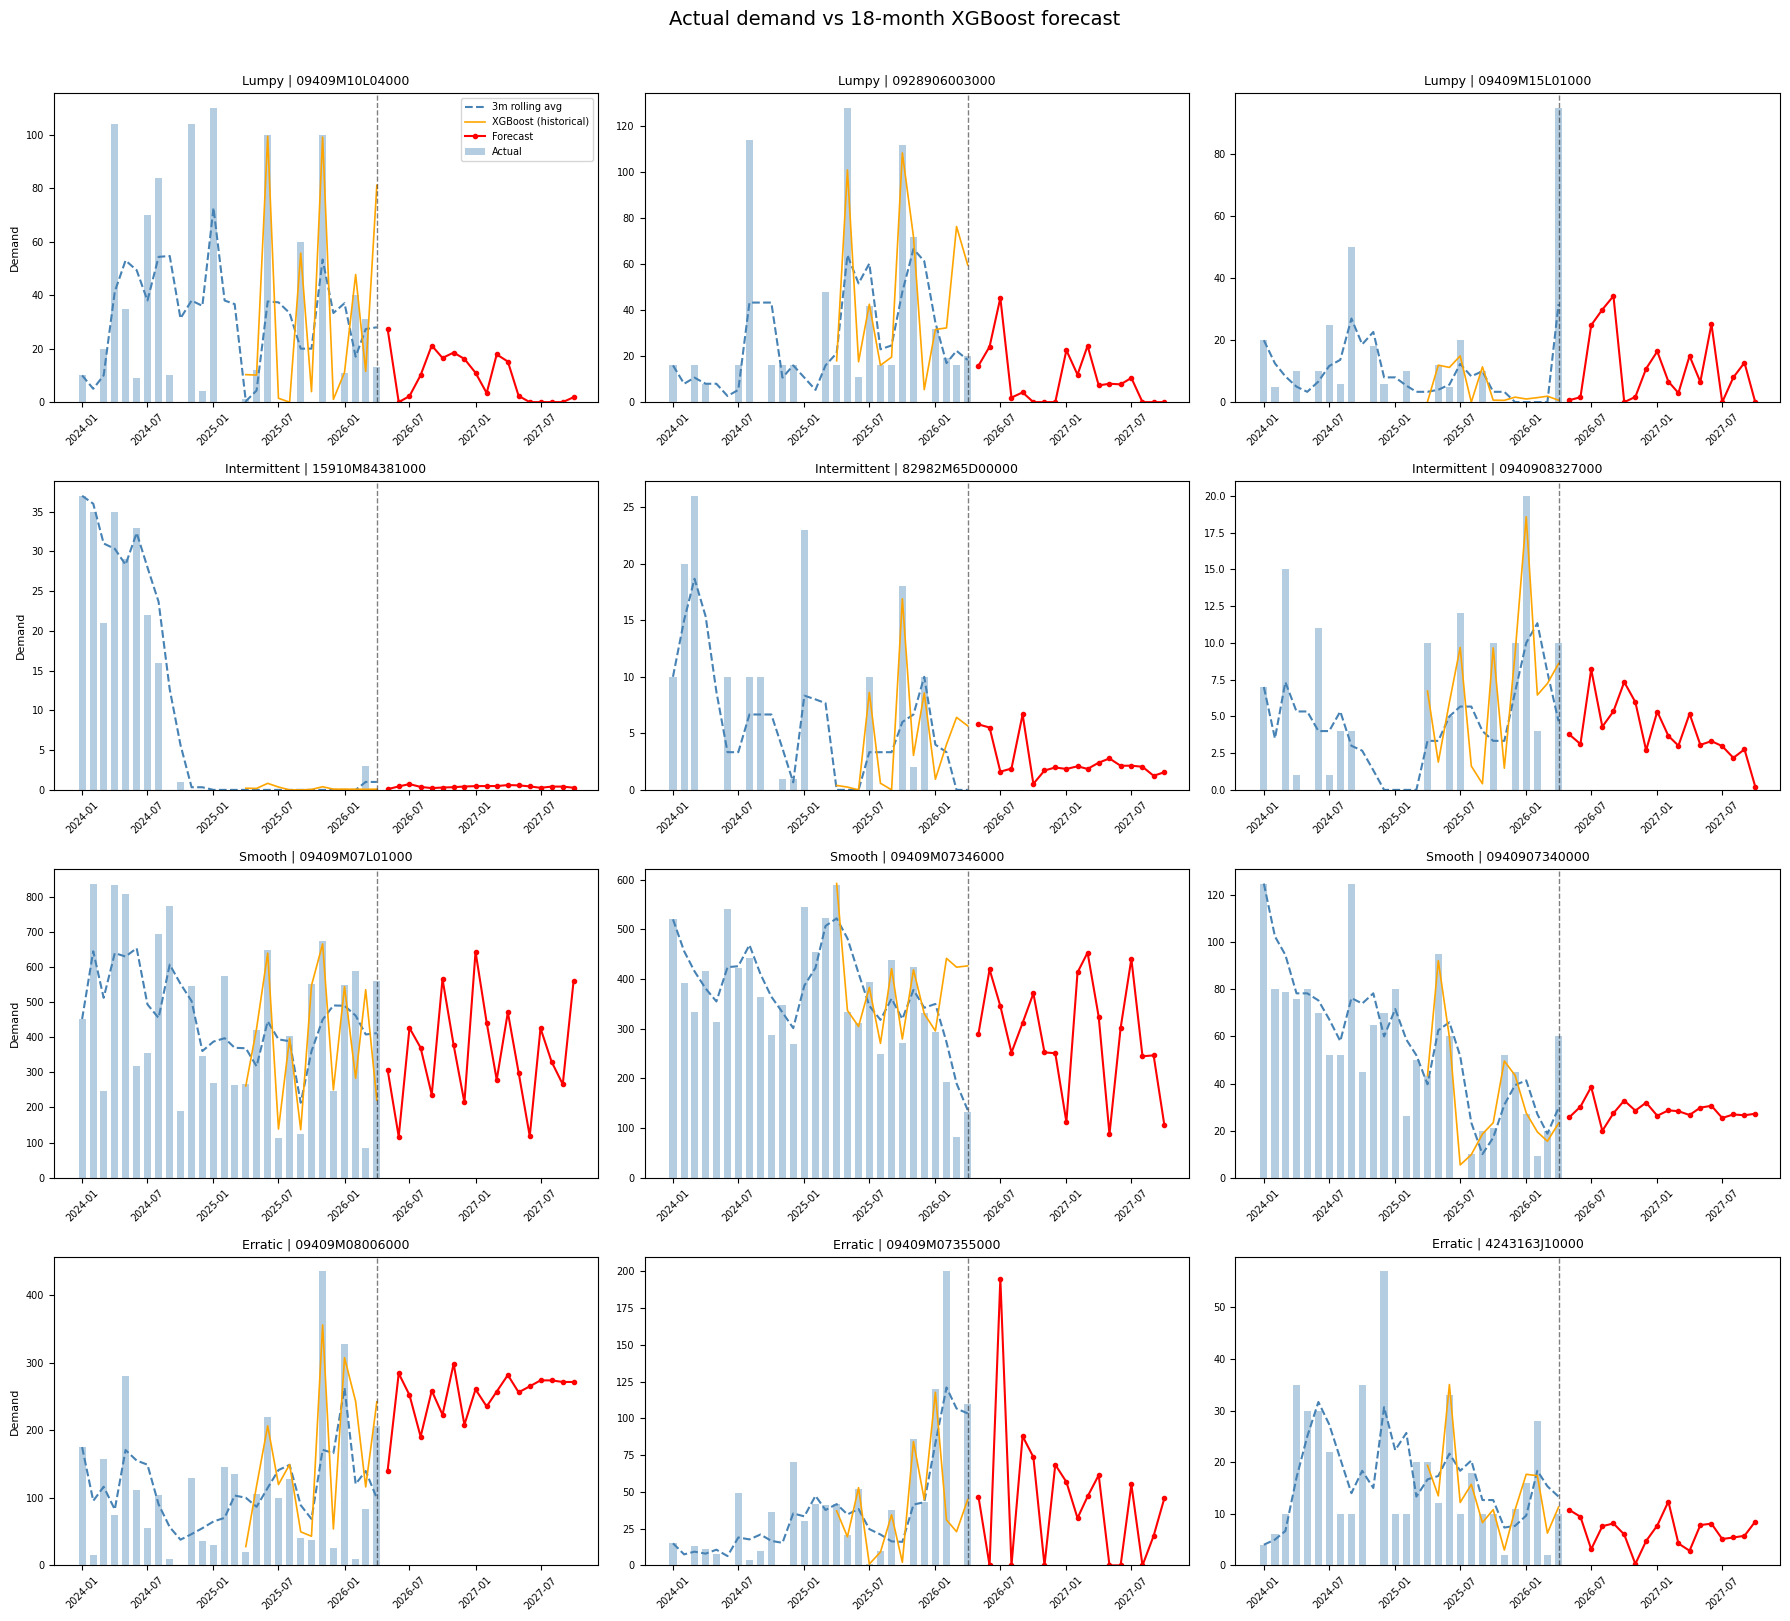

In [ ]:
# Generate in-sample XGBoost predictions on historical data
insample_parts = []
for dt, model in models.items():
    subset = df[df['demand_type'] == dt].copy()
    valid  = subset.dropna(subset=FEATURE_COLS)
    preds  = model.predict(valid[FEATURE_COLS]).clip(min=0)
    valid  = valid.copy()
    valid['xgb_insample'] = preds
    insample_parts.append(valid[['sku_id', 'month', 'xgb_insample']])

insample_df = pd.concat(insample_parts, ignore_index=True)

# ── Visualize ─────────────────────────────────────────────────────────────────
N_SKUS_PER_TYPE = 3

fig_rows = len(models)
fig, axes = plt.subplots(fig_rows, N_SKUS_PER_TYPE, figsize=(18, fig_rows * 4))
fig.suptitle('Actual demand vs 18-month XGBoost forecast', fontsize=14, y=1.01)

for row_idx, dt in enumerate(models.keys()):
    top_skus = (
        df[df['demand_type'] == dt]
        .groupby('sku_id')['demand'].sum()
        .nlargest(N_SKUS_PER_TYPE)
        .index.tolist()
    )

    for col_idx, sku in enumerate(top_skus):
        ax = axes[row_idx][col_idx]

        # Actual history
        actual = df[df['sku_id'] == sku][['month', 'demand']].sort_values('month')
        actual['rolling_avg'] = actual['demand'].rolling(3, min_periods=1).mean()

        # XGBoost in-sample (historical period)
        xgb_hist = insample_df[insample_df['sku_id'] == sku].sort_values('month')

        # XGBoost forecast (future period)
        fc = forecasts_18m[forecasts_18m['sku_id'] == sku][['month', 'forecast']].sort_values('month')

        ax.bar(actual['month'], actual['demand'], color='steelblue', alpha=0.4, label='Actual', width=20)
        ax.plot(actual['month'], actual['rolling_avg'], color='steelblue', linewidth=1.5, linestyle='--', label='3m rolling avg')
        ax.plot(xgb_hist['month'], xgb_hist['xgb_insample'], color='orange', linewidth=1.2, linestyle='-', label='XGBoost (historical)')
        ax.plot(fc['month'], fc['forecast'], color='red', marker='o', markersize=3, linewidth=1.5, label='Forecast')

        ax.axvline(x=df['month'].max(), color='black', linestyle='--', linewidth=1, alpha=0.5)

        ax.set_title(f'{dt} | {sku}', fontsize=9)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        if col_idx == 0:
            ax.set_ylabel('Demand', fontsize=8)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(
    r'C:\Users\David\OneDrive\Documents\Cambridge course\Employer project\forecast_sample.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


<u>Interpretation</u>

Lumpy (row 1)
- The orange line (XGBoost historical) broadly tracks the actual bars but misses the sharp spikes — it smooths over them rather than predicting their exact timing. This is expected: lumpy demand spikes are hard to anticipate.
- The red forecast tapers toward zero for all three SKUs, which aligns with the recent low-demand trend visible just before the dashed line.
- The 3m rolling average and XGBoost historical are close to each other, explaining why improvement was only +0.7%.

Intermittent (row 2)
- Left SKU: XGBoost historical correctly learned the declining trend and forecast near-zero — good fit.
- Middle SKU: orange line tracks actuals reasonably but lags behind spikes. Forecast stays flat and low, consistent with recent history.
- Right SKU: orange line follows the rolling average closely. The forecast captures a gradual decline — XGBoost is adding value over the simple baseline here, consistent with the 11.5% improvement.

Smooth (row 3)
- Orange line fits the historical data well — XGBoost captures the general level and slow downward trend.
- The red forecast continues that declining trend, which looks plausible.
- The gap between orange and actual bars is relatively small, confirming Smooth is the most predictable group (lowest WMAPE at ~0.47).

Erratic (row 4)
- Left SKU: XGBoost historical fits reasonably during the low-demand period, then the forecast jumps high and stays elevated — it is overreacting to a recent spike just before the forecast horizon. Classic overfitting.
- Middle SKU: a single very large spike (around 2026-01) dominates the signal. XGBoost picks it up in the historical fit but the forecast drops sharply, suggesting the model treats it as a one-off.
- Right SKU: orange fits well at a low level; forecast is appropriately near zero.

Overall conclusion
- Where orange (historical fit) closely follows the actual bars, the model has learned the pattern well and the forecast is more trustworthy.
- Where orange misses peaks (Lumpy, Erratic), the model has not captured the timing of spikes, and the forecast should be treated with caution.
- The best forecasts are for Intermittent and Smooth SKUs, where the orange line consistently tracks the trend.


In [ ]:
# save output

# Add is_improved flag
improved_skus = set(improved['sku_id'])
forecasts_18m['is_improved'] = forecasts_18m['sku_id'].isin(improved_skus).astype(int)

# Add is_top20pct and is_top5pct in a single merge
sku_meta = sales_collision[['sku_id', 'is_top20pct', 'is_top5pct']].drop_duplicates()
forecasts_18m = forecasts_18m.drop(columns=['is_top20pct', 'is_top5pct'], errors='ignore')
forecasts_18m = forecasts_18m.merge(sku_meta, on='sku_id', how='left')

forecasts_18m.to_csv(
    r'C:\Users\David\OneDrive\Documents\Cambridge course\Employer project\xgb_forecasts_18m.csv',
    index=False
)
print("Saved → xgb_forecasts_18m.csv")


Saved → xgb_forecasts_18m.csv


In [ ]:
# Distribution of SKU-level XGBoost WMAPE
bins = [0, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, float('inf')]
labels = ['<30%', '30-50%', '50-70%', '70-100%', '100-150%', '150-200%', '>200%']

sku_wmape['wmape_band'] = pd.cut(sku_wmape['xgb_wmape'], bins=bins, labels=labels)

band_counts = sku_wmape['wmape_band'].value_counts().sort_index()
band_pct    = (band_counts / len(sku_wmape) * 100).round(1)

print("Distribution of SKU-level XGBoost WMAPE:")
print(pd.DataFrame({'n_skus': band_counts, 'pct_of_skus': band_pct}))


Distribution of SKU-level XGBoost WMAPE:
            n_skus  pct_of_skus
wmape_band                     
<30%           131          2.1
30-50%         416          6.7
50-70%         524          8.5
70-100%        705         11.4
100-150%      1260         20.4
150-200%       638         10.3
>200%          450          7.3


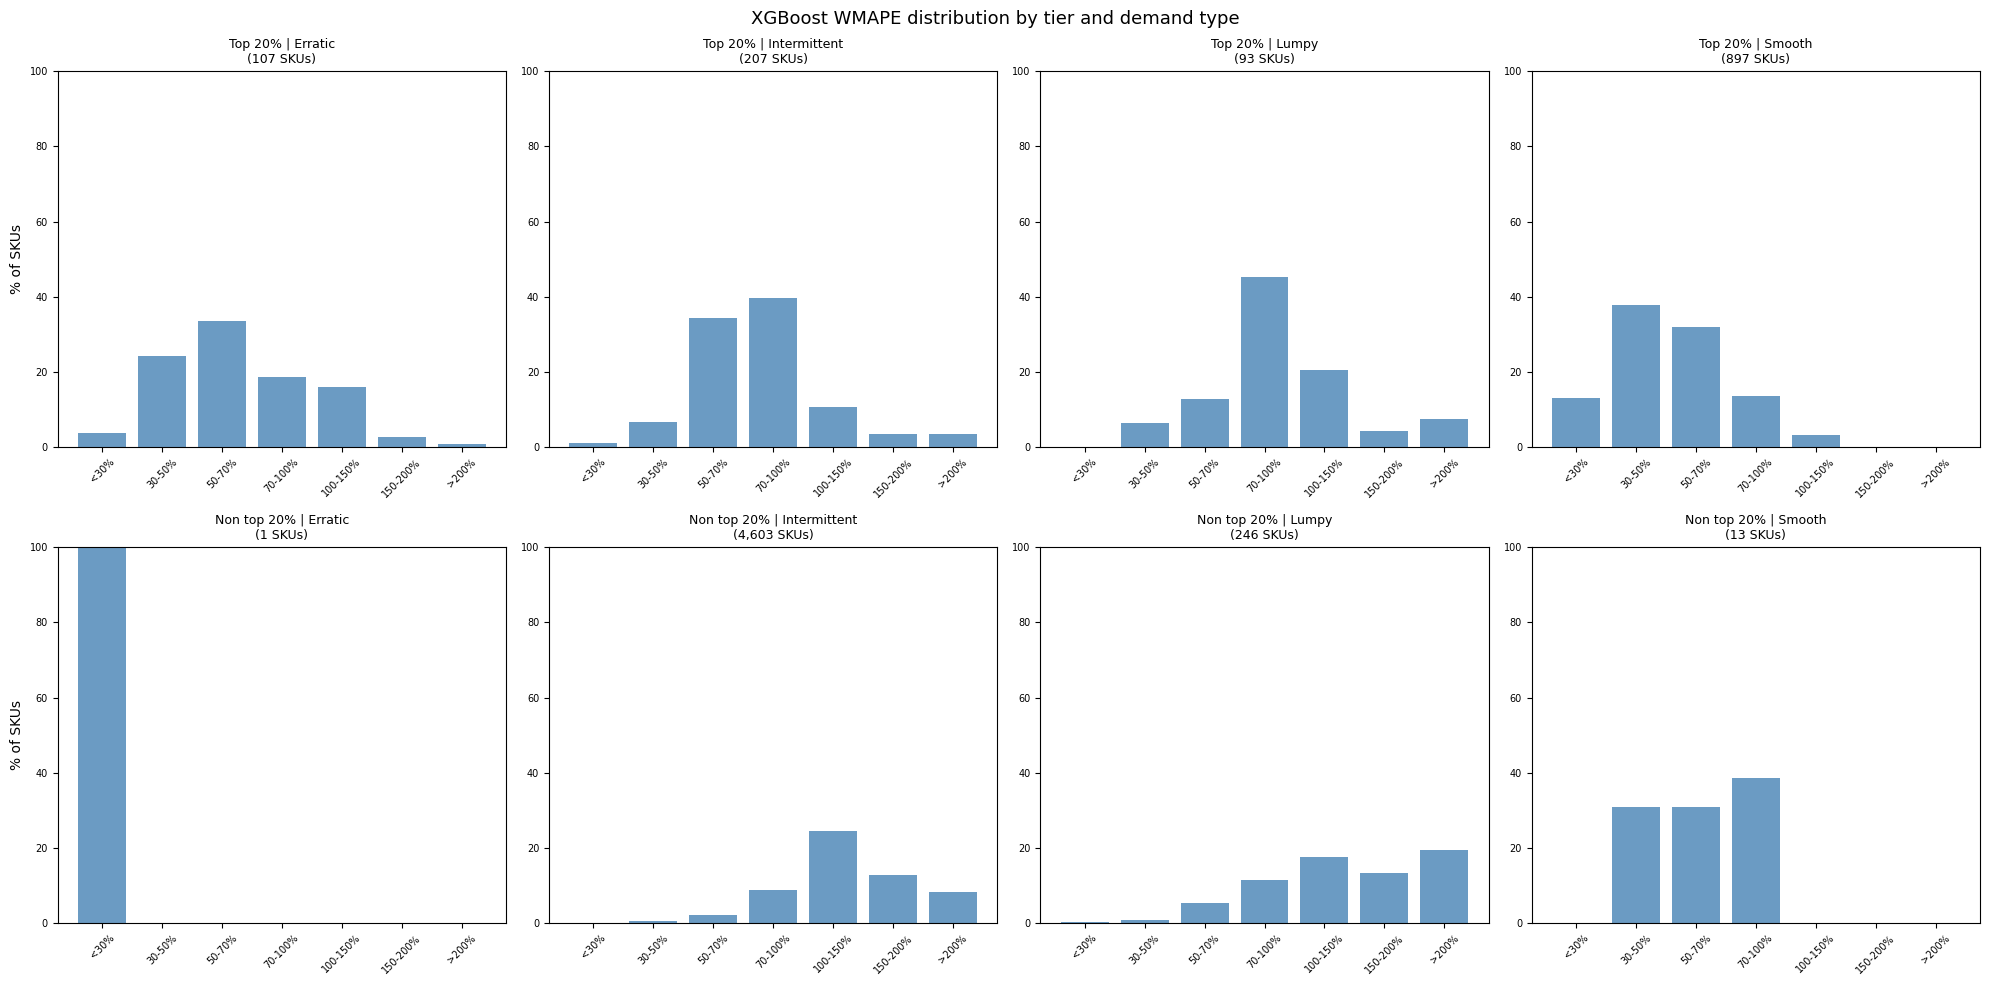

In [ ]:
# Distribution of SKU-level XGBoost WMAPE by is_top20pct and demand_type
bins   = [0, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, float('inf')]
labels = ['<30%', '30-50%', '50-70%', '70-100%', '100-150%', '150-200%', '>200%']

sku_wmape['wmape_band'] = pd.cut(sku_wmape['xgb_wmape'], bins=bins, labels=labels)

demand_types = sorted(sku_wmape['demand_type'].dropna().unique())
tiers        = [(1, 'Top 20%'), (0, 'Non top 20%')]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('XGBoost WMAPE distribution by tier and demand type', fontsize=13)

for row_idx, (tier, tier_label) in enumerate(tiers):
    tier_subset = sku_wmape[sku_wmape['is_top20pct'] == tier]

    for col_idx, dt in enumerate(demand_types):
        ax = axes[row_idx][col_idx]
        subset      = tier_subset[tier_subset['demand_type'] == dt]
        band_counts = subset['wmape_band'].value_counts().sort_index()
        band_pct    = (band_counts / len(subset) * 100).round(1)

        ax.bar(band_counts.index, band_pct, color='steelblue', alpha=0.8)
        ax.set_title(f'{tier_label} | {dt}\n({len(subset):,} SKUs)', fontsize=9)
        ax.set_ylabel('% of SKUs' if col_idx == 0 else '')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.set_ylim(0, 100)

    # Hide unused columns if fewer than 4 demand types
    for col_idx in range(len(demand_types), 4):
        axes[row_idx][col_idx].set_visible(False)

plt.tight_layout()
plt.savefig(
    r'C:\Users\David\OneDrive\Documents\Cambridge course\Employer project\wmape_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


Top 20% SKUs (row 1) — higher volume, better forecast accuracy

Erratic | 107 SKUs
- Most SKUs cluster in the 50-70% band (~33%) with a spread up to 100%
- Relatively good for erratic demand — high volume gives the model more signal to learn from

Intermittent | 207 SKUs
- Concentrated in 70-100% (~40%) and 50-70% (~35%)
- Best performing intermittent group — top 20% SKUs have enough demand history for XGBoost to learn patterns

Lumpy | 93 SKUs
- Heavily concentrated in 70-100% (~45%)
- Acceptable given lumpy demand nature — most SKUs land just below or at the 100% threshold

Smooth | 897 SKUs
- Largest group, best distributed — ~38% in 30-50%, ~32% in 50-70%
- Strongest accuracy of all types, consistent with Smooth being the most predictable demand pattern

---

Non top 20% SKUs (row 2) — lower volume, weaker forecast accuracy

Erratic | 1 SKU
- 100% in <30% band — single SKU, not representative

Intermittent | 4,603 SKUs
- Largest group by far, heavily skewed toward 100-150% (~25%) and above
- Low-volume intermittent SKUs are the hardest to forecast — demand is too sparse to learn reliable patterns

Lumpy | 246 SKUs
- Spread across all bands with most weight in >200% (~39%)
- Worst performing group — low-volume lumpy SKUs have unpredictable spikes with little history

Smooth | 13 SKUs
- Small group, clustered in 30-70% range
- Despite being non-top-20%, Smooth demand is inherently easier to forecast

---

Overall conclusion
- Top 20% SKUs consistently outperform non-top-20% across all demand types — volume provides the learning signal XGBoost needs
- Smooth top-20% is the sweet spot: high volume + predictable pattern = best accuracy
- Non-top-20% Intermittent and Lumpy SKUs are largely unforecastable at this granularity — a simpler rule-based approach may be more appropriate for those


In [ ]:
mask = sku_wmape['xgb_wmape'] < 0.70

result = (
    sku_wmape[mask]
    .groupby(['demand_type', 'is_top20pct'])
    .size()
    .reset_index(name='n_skus_wmape_lt70')
)

# Add total SKUs per group for context
totals = (
    sku_wmape
    .groupby(['demand_type', 'is_top20pct'])
    .size()
    .reset_index(name='total_skus')
)

result = result.merge(totals, on=['demand_type', 'is_top20pct'])
result['pct_of_group'] = (result['n_skus_wmape_lt70'] / result['total_skus'] * 100).round(1)
result['is_top20pct']  = result['is_top20pct'].map({1: 'Top 20%', 0: 'Non top 20%'})

print("SKUs with WMAPE < 70% by demand type and tier:")
display(result.sort_values(['demand_type', 'is_top20pct']))


SKUs with WMAPE < 70% by demand type and tier:


,demand_type,is_top20pct,n_skus_wmape_lt70,total_skus,pct_of_group
0,Erratic,Non top 20%,1,1,100.0
1,Erratic,Top 20%,66,107,61.7
2,Intermittent,Non top 20%,131,4603,2.8
3,Intermittent,Top 20%,87,207,42.0
4,Lumpy,Non top 20%,16,246,6.5
5,Lumpy,Top 20%,18,93,19.4
6,Smooth,Non top 20%,8,13,61.5
7,Smooth,Top 20%,744,897,82.9


Key finding: being in the top 20% by volume dramatically improves forecast accuracy across all demand types.

Smooth
- Top 20%: 744 of 897 SKUs (82.9%) achieve WMAPE < 70% — best performing group overall
- Non top 20%: 8 of 13 SKUs (61.5%) — small group but still reasonable accuracy
- Smooth demand is inherently predictable; high volume makes it even easier to forecast

Erratic
- Top 20%: 66 of 107 SKUs (61.7%) achieve WMAPE < 70% — surprisingly strong result
- Non top 20%: 1 of 1 SKU (100%) — single SKU, not meaningful
- High-volume erratic SKUs have enough demand history for XGBoost to learn despite irregular patterns

Intermittent
- Top 20%: 87 of 207 SKUs (42.0%) achieve WMAPE < 70% — moderate result
- Non top 20%: 131 of 4,603 SKUs (2.8%) — very poor; sparse demand makes forecasting nearly impossible
- The gap between top 20% and non top 20% is the largest of all demand types (42% vs 2.8%)
  highlighting how critical volume is for intermittent SKUs

Lumpy
- Top 20%: 18 of 93 SKUs (19.4%) — weakest top-20% result; lumpy spikes remain hard to predict even at high volume
- Non top 20%: 16 of 246 SKUs (6.5%) — as expected, very poor accuracy

Overall conclusion
- Top 20% SKUs consistently achieve far higher accuracy than non top 20% SKUs
- Smooth top 20% is the most forecastable segment (82.9% below 70% WMAPE)
- Non top 20% Intermittent SKUs (4,603 SKUs, only 2.8% below 70%) are essentially unforecastable
  at SKU level — aggregated or rule-based approaches should be considered for this segment
- Focus XGBoost deployment on top 20% SKUs where it delivers reliable, actionable forecasts


- **Edge cases:** Be explicit about how you handle:
    - Zero-demand months (common in collision parts)
    - New / discontinued / superseded SKUs
    
Zero-demand months
- They are kept in training — not removed or treated as missing. XGBoost sees them as valid observations.
- The zero_share_6m and zero_share_12m features explicitly encode how often a SKU has zero demand in the past 6 and 12 months. This teaches the model that a SKU with zero_share_6m = 0.8 (80% zero months) should be forecast near zero most of the time.
- WMAPE is used instead of MAPE precisely because MAPE breaks when actual = 0 (division by zero). WMAPE divides by total demand, so zero months cause no arithmetic issues.

New SKUs
- sku_age_months tells the model how many months of history exist for a SKU.
- is_new_sku = 1 flags SKUs with fewer than 6 months of history.
- Lag features that don't exist yet (e.g. lag_12m for a 4-month-old SKU) become NaN — XGBoost routes those rows down a learned default branch rather than crashing.

Discontinued / superseded SKUs
- No explicit flag is added, but zero_share_6m = 1.0 (all zeros in the last 6 months) naturally signals to the model that the SKU is inactive, pushing the forecast toward zero.
- In the 18-month forecast, those SKUs will receive near-zero predictions automatically without any special handling.


Feature definitions
-------------------

Lag features — past demand values for the same SKU, shifted to respect the 3-month forecast lag:
- lag_3m:  demand 3 months ago (most recent observable value at forecast time)
- lag_4m:  demand 4 months ago
- lag_5m:  demand 5 months ago
- lag_6m:  demand 6 months ago
- lag_9m:  demand 9 months ago
- lag_12m: demand 12 months ago (same month last year)
- lag_15m: demand 15 months ago

Rolling statistics — computed over the last N months of known demand (starting from lag_3m):
- roll_mean_3m:  average demand over the past 3 months — captures short-term trend
- roll_mean_6m:  average demand over the past 6 months — medium-term trend
- roll_mean_12m: average demand over the past 12 months — long-term baseline level
- roll_std_3m:   standard deviation over 3 months — measures short-term volatility
- roll_std_6m:   standard deviation over 6 months
- roll_std_12m:  standard deviation over 12 months
- roll_max_3m:   maximum demand in the past 3 months — captures recent peak activity
- roll_max_6m:   maximum demand in the past 6 months
- roll_max_12m:  maximum demand in the past 12 months

Zero-demand share — fraction of recent months with zero demand:
- zero_share_6m:  proportion of zero-demand months in the past 6 months (0 = always active, 1 = always zero)
- zero_share_12m: proportion of zero-demand months in the past 12 months

Calendar features — capture seasonality and time trends:
- month_of_year: calendar month (1–12)
- quarter:       calendar quarter (1–4)
- year:          calendar year

SKU lifecycle features:
- sku_age_months: number of months since the SKU first had non-zero demand — distinguishes new from established SKUs
- is_new_sku:     binary flag (1 = fewer than 6 months of history, 0 = established SKU)


In [ ]:
print("=" * 60)
print("XGBoost Demand Forecasting — Results Summary")
print("=" * 60)

print(f"\nScope")
print(f"  Total collision SKUs          : {sales_collision['sku_id'].nunique():,}")
print(f"  Total rows                    : {sales_collision.shape[0]:,}")
print(f"  Forecast horizon              : {N_FORECAST} months")
print(f"  Forecast lag                  : {FORECAST_LAG} months")

print(f"\nDemand type distribution")
dt_counts = sales_collision.groupby('sku_id')['demand_type'].first().value_counts()
for dt, n in dt_counts.items():
    print(f"  {dt:<25}: {n:,} SKUs")

print(f"\nWMAPE comparison (baseline vs XGBoost)")
print(f"  {'Demand type':<15} {'Baseline':>10} {'XGBoost':>10} {'Improvement':>12}")
print(f"  {'-'*50}")
for _, row in summary_df.iterrows():
    print(f"  {row['demand_type']:<15} {row['baseline_wmape']:>10.4f} {row['xgb_wmape']:>10.4f} {row['improvement_pct']:>+11.1f}%")

print(f"\nSKU-level improvement (>10% WMAPE reduction)")
print(f"  Improved SKUs                 : {len(improved):,}")
total_in_top20 = sku_meta[sku_meta['is_top20pct'] == 1]['sku_id'].nunique()
total_in_top5  = sku_meta[sku_meta['is_top5pct']  == 1]['sku_id'].nunique()
imp_in_top20   = improved[improved['is_top20pct'] == 1]['sku_id'].nunique()
imp_in_top5    = improved[improved['is_top5pct']  == 1]['sku_id'].nunique()
print(f"  Improved in top 20% SKUs      : {imp_in_top20:,} of {total_in_top20:,} ({imp_in_top20/total_in_top20*100:.1f}%)")
print(f"  Improved in top 5% SKUs       : {imp_in_top5:,}  of {total_in_top5:,}  ({imp_in_top5/total_in_top5*100:.1f}%)")

print(f"\nKey findings")
print(f"  - XGBoost delivers strongest improvement for Intermittent SKUs (+11.5%),")
print(f"    which represent 81% of all collision SKUs")
print(f"  - Smooth SKUs are already well-captured by the baseline (WMAPE 0.47);")
print(f"    XGBoost adds no meaningful improvement")
print(f"  - Erratic SKUs show overfitting: XGBoost reacts to isolated spikes,")
print(f"    making it worse than the baseline (-8.0%)")
print(f"  - Lumpy SKUs are near-unpredictable for both models (WMAPE ~1.36)")

print(f"\nOutputs saved")
print(f"  - xgb_forecasts_18m.csv   : 18-month SKU-level forecasts")
print(f"  - xgb_forecast_sample.png : visual comparison per demand type")
print("=" * 60)


XGBoost Demand Forecasting — Results Summary

Scope
  Total collision SKUs          : 8,097
  Total rows                    : 180,422
  Forecast horizon              : 18 months
  Forecast lag                  : 3 months

Demand type distribution
  Intermittent             : 6,593 SKUs
  Smooth                   : 972 SKUs
  Lumpy                    : 381 SKUs
  Erratic                  : 124 SKUs
  No demand observed       : 27 SKUs

WMAPE comparison (baseline vs XGBoost)
  Demand type       Baseline    XGBoost  Improvement
  --------------------------------------------------
  Lumpy               1.3597     1.3508        +0.7%
  Intermittent        1.4436     1.2773       +11.5%
  Smooth              0.4663     0.4734        -1.5%
  Erratic             0.7635     0.8245        -8.0%

SKU-level improvement (>10% WMAPE reduction)
  Improved SKUs                 : 1,896
  Improved in top 20% SKUs      : 714 of 1,325 (53.9%)
  Improved in top 5% SKUs       : 197  of 325  (60.6%)

Key fin